# IVFPQ vs. KNN Accuracy and Performance

SCimilarity uses TileDB KNN IVF_FLAT index which provides exact vector similarity search.

Cytoverse quantizes the vectors via Product Quantization (PQ) and then performs an approximate lookup based on partitions in an Inverted File Index (IVF) fetched over HTTP.

Note: The memory calculations use tracemalloc.test_traced_memory() and are only valid from a fresh run of this notebook on a restarted kernel. We call gc.collect() to attempt a clean measurement between each set of parameters


In [1]:
import os
from pathlib import Path
from typing import Tuple
from collections import Counter
import time
from tqdm.notebook import tqdm
import tracemalloc
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata
import torch

from scimilarity import CellAnnotation
from scimilarity.utils import align_dataset, lognorm_counts

from ivfpq import IVFPQ

In [2]:
def get_folder_size(folder_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            total_size += os.path.getsize(file_path)
    return total_size

In [ ]:
# Load a randomly selected subset of the SCimilarity tutorial test file
adata = anndata.read_h5ad("tests/fixtures/GSE136831_subsample_100.h5ad")
print(f"Loaded test data shape: {adata.shape}")
n_queries = adata.shape[0]

# For all tests we'll look for 50 neighbors
k_neighbors = 50

# IVFPQ search parameters to vary
n_subs = [8, 16, 32]  # Number of IVF partitions
n_probes = [1, 2, 3, 4, 6, 8, 16, 32]  # More realistic range for IVFPQ

# Debug/Dev
# n_subs = [8, 16]  # Number of IVF partitions
# n_probes = [1, 2, 4]  # More realistic range for IVFPQ


# Load reference labels which are the same in both datasets
reference_labels = pd.read_parquet("data/references/scimilarity/labels.parquet")

Loaded test data shape: (100, 44942)


## Compute Exact Neighbors via KNN


In [4]:
def get_scimilarity_predictions(
    adata: anndata.AnnData, model_path: Path, k_neighbors: int = 50
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, dict]:
    """
    Get cell type predictions using SCimilarity.

    Returns:
        embeddings: Cell embeddings [n_cells, embedding_dim]
        predictions: Cell type predictions [n_cells]
        nn_idxs: Indices of nearest neighbors [n_cells, k_neighbors]
        nn_dists: Cosine distances to nearest neighbors [n_cells, k_neighbors]
        stats: Statistics about the predictions
    """
    # Load SCimilarity model
    cell_annotation = CellAnnotation(model_path, use_gpu=False)

    # Align and normalize
    adata_aligned = align_dataset(adata, cell_annotation.gene_order)
    adata_normalized = lognorm_counts(adata_aligned)

    # Get embeddings
    embeddings = cell_annotation.get_embeddings(adata_normalized.X)

    # Get predictions
    predictions, nn_idxs, nn_dists, stats = cell_annotation.get_predictions_knn(
        embeddings, k=k_neighbors, disable_progress=True, weighting=True
    )

    return embeddings, predictions, nn_idxs, nn_dists, stats


# Reset counters
tracemalloc.stop()
tracemalloc.start()

# Force GC to clean up for the next call
gc.collect()

knn_before_current, knn_before_peak = tracemalloc.get_traced_memory()
start_time = time.time()

embeddings, knn_predictions, knn_idxs, knn_dists, sc_stats = (
    get_scimilarity_predictions(
        adata, "data/models/scimilarity/model_v1.1", k_neighbors=k_neighbors
    )
)
end_time = time.time()

knn_time = end_time - start_time

knn_after_current, knn_after_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Using memory consumption as a proxy for bw
knn_bw = knn_after_peak - knn_before_current

# Use the on disk storage of the annotation tiledb/knn (7M cells vs. 23M overall)
knn_storage = get_folder_size("data/models/scimilarity/model_v1.1/annotation")

# Convert row indices to category indices (codes)
knn_labels = [
    [reference_labels["prediction"].cat.codes.iloc[idx] for idx in inner]
    for inner in knn_idxs
]

knn_labels = np.array(knn_labels, dtype=object)


print(f"KNN execution time: {knn_time:.4f} seconds")
print(f"KNN memory (~bandwidth) usage: {knn_bw / 2**20:.2f} MiB")
print(f"KNN peak memory usage: {knn_after_peak / 2**20:.2f} MiB")
print(f"KNN on-disk storage: {knn_storage / 2**20:.2f} MiB")

KNN execution time: 43.3093 seconds
KNN memory (~bandwidth) usage: 1085.56 MiB
KNN peak memory usage: 1085.57 MiB
KNN on-disk storage: 9023.19 MiB


## Compute Approximate IVFPQ Neighbors


In [5]:
def get_ivfpq_predictions(
    embeddings: np.ndarray,
    model_path: Path,
    reference_labels: pd.DataFrame,
    k_neighbors: int = 50,
    n_partitions_search: int = 4,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Get cell type predictions using IVFPQ with batched processing.

    Returns:
        predictions: Predicted cell type labels [n_cells]
        nn_idxs: Indices of nearest neighbors [n_cells, k_neighbors]
        nn_dists: Cosine distances to nearest neighbors [n_cells, k_neighbors]
        nn_labels: Labels of nearest neighbors [n_cells, k_neighbors]
    """

    ivf = IVFPQ.load(model_path)

    predictions = []
    nn_idxs = []
    nn_dists = []
    nn_labels = []

    for embedding in embeddings:
        # Assume normalized so we can compare distances
        assert np.isclose(np.linalg.norm(embedding), 1.0)

        # Convert to torch tensor
        query_vector = torch.from_numpy(embedding).float()

        # Search using IVFPQ
        vector_ids, distances = ivf.search(
            query_vector=query_vector,
            model_path=model_path,
            n_probe=n_partitions_search,
        )

        # Convert euclidean squared distances to cosine distances to compare with SCimilarity
        # Assumes embeddings are normalized
        cosine_distances = np.array(distances) / 2.0

        # Convert to numpy arrays and limit to k_neighbors
        nn_idxs.append(np.array(vector_ids[:k_neighbors]))
        nn_dists.append(np.array(cosine_distances[:k_neighbors]))

        # Get labels for nearest neighbors
        neighbor_labels = []
        for vec_id in vector_ids[:k_neighbors]:  # Ensure we only use k neighbors
            if vec_id < len(reference_labels):
                # Get the "prediction" column from reference labels
                label = reference_labels.iloc[vec_id]["prediction"]
                neighbor_labels.append(label)

        nn_labels.append(neighbor_labels)

        # Vote for most common label (simple majority voting)
        if neighbor_labels:
            label_counts = Counter(neighbor_labels)
            predicted_label = label_counts.most_common(1)[0][0]
        else:
            predicted_label = "Unknown"

        predictions.append(predicted_label)

    # Stack arrays to create proper 2D numpy arrays
    return (
        np.array(predictions),
        np.vstack(nn_idxs),  # Creates [n_cells, k_neighbors] array
        np.vstack(nn_dists),  # Creates [n_cells, k_neighbors] array
        np.array(nn_labels, dtype=object),
    )


ivfpq_data = {}

for n_sub in tqdm(n_subs, desc="IVF partitions", leave=True, position=0):
    for n_probe in tqdm(
        n_probes, desc=f"Probes (n_sub={n_sub})", leave=False, position=1
    ):
        # Reset counters
        tracemalloc.stop()
        tracemalloc.start()

        # Force GC to clean up for the next call
        gc.collect()

        ivfpq_before_current, ivfpq_before_peak = tracemalloc.get_traced_memory()
        start_time = time.time()

        ivfpq_path = Path(f"data/ivfpq{n_sub}x256")

        ivfpq_predictions, ivfpq_idxs, ivfpq_dists, ivfpq_labels = (
            get_ivfpq_predictions(
                embeddings,
                ivfpq_path,
                reference_labels=reference_labels,
                k_neighbors=k_neighbors,
                n_partitions_search=n_probe,
            )
        )
        end_time = time.time()
        ivfpq_time = end_time - start_time
        ivfpq_after_current, ivfpq_after_peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        # Convert row indices to category indices (codes)
        ivfpq_labels = [
            [reference_labels["prediction"].cat.codes.iloc[idx] for idx in inner]
            for inner in ivfpq_idxs
        ]

        ivfpq_labels = np.array(ivfpq_labels, dtype=object)
        ivfpq_data[(n_sub, n_probe)] = {
            "ivfpq_idxs": ivfpq_idxs,
            "ivfpq_labels": ivfpq_labels,
            "ivfpq_dists": ivfpq_dists,
            "ivfpq_time": ivfpq_time,
            "ivfpq_bw": ivfpq_after_peak - ivfpq_before_current,
            "ivfpq_storage": get_folder_size(ivfpq_path),
        }

IVF partitions:   0%|          | 0/2 [00:00<?, ?it/s]

Probes (n_sub=8):   0%|          | 0/3 [00:00<?, ?it/s]

Probes (n_sub=16):   0%|          | 0/3 [00:00<?, ?it/s]

## Summary


In [15]:
def compute_recall(knn_idxs, ivfpq_idxs, k):
    """
    Compute mean recall@K: fraction of exact KNN neighbors in IVFPQ results.
    Averages over all queries.
    """
    n_queries = knn_idxs.shape[0]
    recalls = []
    for q in range(n_queries):
        true_set = set(knn_idxs[q])
        approx_set = set(ivfpq_idxs[q])
        intersection = len(true_set & approx_set)
        recalls.append(intersection / k)
    return np.mean(recalls)


def generate_summary_table(
    knn_idxs,
    knn_time,
    knn_storage,
    ivfpq_data,
    k_neighbors,
    n_subs,
    selected_probes=[1, 5, 10],
):
    """
    Generate a Pandas DataFrame for the Summary Table.
    Assumptions on input data:
    - knn_idxs: NumPy array [n_queries, k_neighbors] of integer indices (exact KNN neighbors).
    - knn_time: float, total time in seconds for all queries using exact KNN.
    - knn_storage: float, bytes required for the entire KNN index.
    - ivfpq_data: dict with keys as tuples (n_sub, n_probe), values as dicts containing:
      - 'ivfpq_idxs': NumPy array [n_queries, k_neighbors] of integer indices.
      - 'ivfpq_time': float, total time in seconds for all queries.
      - 'ivfpq_bw': float, total bytes pulled over HTTP for all queries.
      - 'ivfpq_storage': float, bytes required for the entire IVFPQ index (may be same for same n_sub).
    - k_neighbors: int, used for recall@K.
    - n_subs: list of ints, e.g., [8, 16, 32].
    - selected_probes: list of ints, e.g., [1, 5, 10] for low/medium/high probes per n_sub.
    - All data is pre-computed; missing combos are skipped.
    - Storage and bandwidth converted from bytes to MB (divide by 1024**2).
    - KNN row added as baseline with Recall=1.0, Speedup=1.0, Reduction=1.0, Bandwidth=0.
    - In Jupyter, the returned DF will display automatically if at cell end; else use display(df).
    """
    rows = []

    # Add IVFPQ rows
    for n_sub in n_subs:
        for n_probe in selected_probes:
            key = (n_sub, n_probe)
            if key in ivfpq_data:
                data = ivfpq_data[key]
                recall = compute_recall(knn_idxs, data["ivfpq_idxs"], k_neighbors)
                time = data["ivfpq_time"]
                speedup = knn_time / time if time > 0 else np.nan
                storage_bytes = data["ivfpq_storage"]
                storage_mb = storage_bytes / (1024**2)
                reduction = knn_storage / storage_bytes if storage_bytes > 0 else np.nan
                bw_mb = data["ivfpq_bw"] / (1024**2)

                rows.append(
                    {
                        "n_sub": n_sub,
                        "n_probe": n_probe,
                        "Recall@K": round(recall, 3),
                        "Query Time (s)": round(time, 2),
                        "Speedup": round(speedup, 2),
                        "Storage (MB)": round(storage_mb, 2),
                        "Storage Reduction": round(reduction, 2),
                        "Bandwidth (MB)": round(bw_mb, 2),
                    }
                )

    # Add KNN baseline row
    knn_storage_mb = knn_storage / (1024**2)
    rows.append(
        {
            "n_sub": "KNN",
            "n_probe": "N/A",
            "Recall@K": 1.0,
            "Query Time (s)": round(knn_time, 2),
            "Speedup": 1.0,
            "Storage (MB)": round(knn_storage_mb, 2),
            "Storage Reduction": 1.0,
            "Bandwidth (MB)": 0.0,
        }
    )

    df = pd.DataFrame(rows)
    # Sort by n_sub and n_probe for better readability
    df = df.sort_values(by=["n_sub", "n_probe"], na_position="last")
    return df


df = generate_summary_table(
    knn_idxs,
    knn_time,
    knn_storage,
    ivfpq_data,
    k_neighbors=k_neighbors,
    n_subs=[8, 16, 32],
)

df.to_csv("notebooks/summary.csv", index=False)

# Save as png to disk to match others...

# Create a figure and axis
fig, ax = plt.subplots()

# Hide axes
ax.axis("off")

# Create a table from the DataFrame
table = ax.table(
    cellText=df.values, colLabels=df.columns, loc="center", cellLoc="center"
)

# Adjust table appearance (optional)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)  # Scale table size

# Save the figure to disk
plt.savefig("notebooks/summary.png", bbox_inches="tight", dpi=300)
plt.close()

df

,n_sub,n_probe,Recall@K,Query Time (s),Speedup,Storage (MB),Storage Reduction,Bandwidth (MB)
0,8,1,0.442,1.97,21.96,92.30,97.76,3.05
1,16,1,0.519,1.85,23.38,152.71,59.09,3.05
2,KNN,N/A,1.000,43.31,1.00,9023.19,1.00,0.00


## Recall vs. Probes

IVFPQ recall improves with more probes but plateaus. Fewer subspaces trade accuracy for compression reducing server storage and bandwidth.


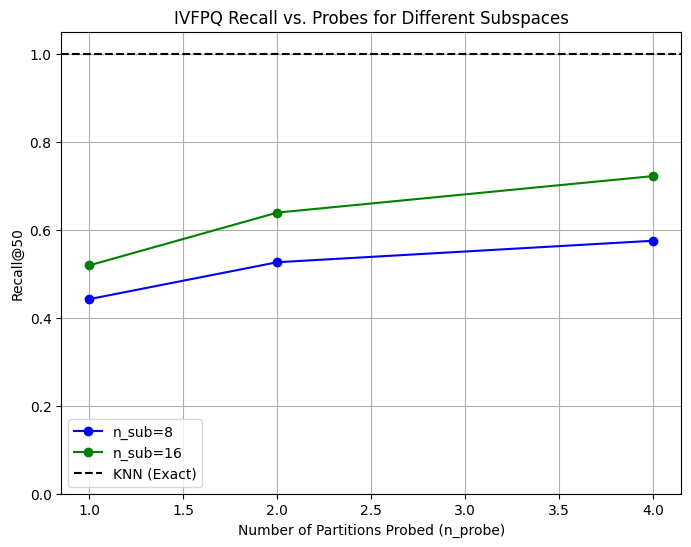

In [7]:
def compute_recall(knn_idxs, ivfpq_idxs, k):
    """
    Compute mean recall@K: fraction of exact KNN neighbors in IVFPQ results.
    Averages over all queries.
    """
    n_queries = knn_idxs.shape[0]
    recalls = []
    for q in range(n_queries):
        true_set = set(knn_idxs[q])
        approx_set = set(ivfpq_idxs[q])
        intersection = len(true_set & approx_set)
        recalls.append(intersection / k)
    return np.mean(recalls)


def plot_recall_vs_probes(knn_idxs, ivfpq_data, k_neighbors, n_subs, n_probes):
    plt.figure(figsize=(8, 6))
    colors = ["b", "g", "r"]  # One per n_sub

    for i, n_sub in enumerate(n_subs):
        recalls = []
        for n_probe in n_probes:
            key = (n_sub, n_probe)
            if key in ivfpq_data:
                ivfpq_idxs = ivfpq_data[key]["ivfpq_idxs"]
                recall = compute_recall(knn_idxs, ivfpq_idxs, k_neighbors)
                recalls.append(recall)
            else:
                recalls.append(np.nan)  # Skip missing data

        plt.plot(n_probes, recalls, marker="o", color=colors[i], label=f"n_sub={n_sub}")

    # KNN baseline
    plt.axhline(y=1.0, color="k", linestyle="--", label="KNN (Exact)")

    plt.xlabel("Number of Partitions Probed (n_probe)")
    plt.ylabel(f"Recall@{k_neighbors}")
    plt.title("IVFPQ Recall vs. Probes for Different Subspaces")
    plt.legend()
    plt.grid(True)
    plt.ylim(0, 1.05)
    plt.savefig("notebooks/recall_vs_probes.png")  # Or plt.show() for display
    plt.show()
    plt.close()


plot_recall_vs_probes(
    knn_idxs, ivfpq_data, k_neighbors=k_neighbors, n_subs=n_subs, n_probes=n_probes
)

## Time and Bandwidth vs. Probes


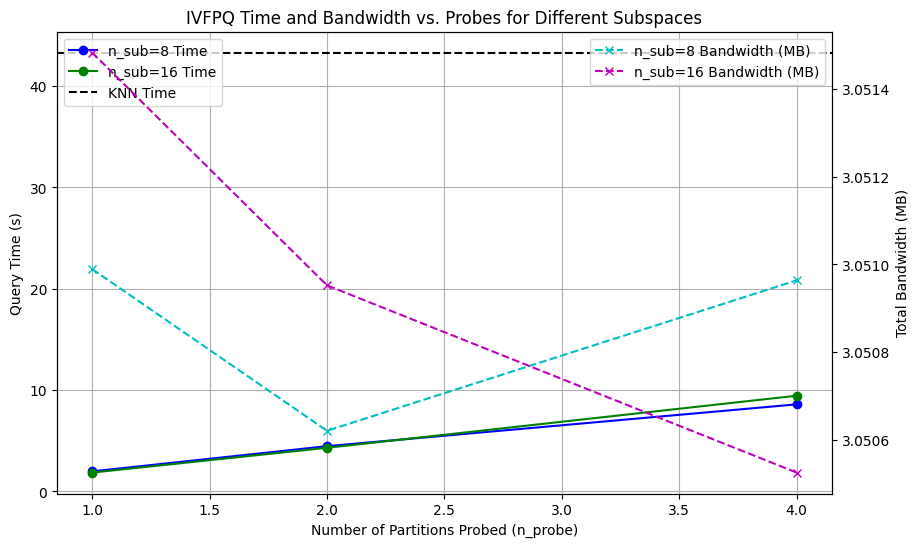

In [8]:
import numpy as np
import matplotlib.pyplot as plt


def plot_time_bw_vs_probes(knn_time, ivfpq_data, n_subs, n_probes):
    """
    Generate twin-axis line plot for Query Time (left) and Bandwidth (right) vs. n_probe.
    Assumptions:
    - knn_time: float, total time in seconds for all queries using exact KNN.
    - ivfpq_data: dict with keys as tuples (n_sub, n_probe), values as dicts containing:
      - 'ivfpq_time': float, total time in seconds for all queries.
      - 'ivfpq_bw': float, total bytes pulled over HTTP for all queries (will be converted to MB).
    - n_subs: list of ints, e.g., [8, 16, 32].
    - n_probes: list or range of ints, e.g., range(1, 11).
    - All data is pre-computed from experiments; missing combos are skipped (plotted as NaN).
    - Bandwidth is converted from bytes to MB (divide by 1024**2).
    - KNN has no bandwidth, so only plotted on time axis as horizontal dashed line.
    """
    fig, ax1 = plt.subplots(figsize=(10, 6))
    colors = ["b", "g", "r"]  # One color per n_sub for time lines

    # Plot times on primary axis (left)
    for i, n_sub in enumerate(n_subs):
        times = []
        for n_probe in n_probes:
            key = (n_sub, n_probe)
            if key in ivfpq_data:
                times.append(ivfpq_data[key]["ivfpq_time"])
            else:
                times.append(np.nan)

        ax1.plot(
            n_probes, times, marker="o", color=colors[i], label=f"n_sub={n_sub} Time"
        )

    # KNN baseline time
    ax1.axhline(y=knn_time, color="k", linestyle="--", label="KNN Time")

    ax1.set_xlabel("Number of Partitions Probed (n_probe)")
    ax1.set_ylabel("Query Time (s)")
    ax1.set_title("IVFPQ Time and Bandwidth vs. Probes for Different Subspaces")
    ax1.grid(True)
    ax1.legend(loc="upper left")

    # Twin axis for bandwidth (right)
    ax2 = ax1.twinx()
    bw_colors = ["c", "m", "y"]  # Different colors for bandwidth dashed lines

    for i, n_sub in enumerate(n_subs):
        bws = []
        for n_probe in n_probes:
            key = (n_sub, n_probe)
            if key in ivfpq_data:
                bw_bytes = ivfpq_data[key]["ivfpq_bw"]
                bw_mb = bw_bytes / (1024**2)  # Convert to MB
                bws.append(bw_mb)
            else:
                bws.append(np.nan)

        ax2.plot(
            n_probes,
            bws,
            marker="x",
            linestyle="--",
            color=bw_colors[i],
            label=f"n_sub={n_sub} Bandwidth (MB)",
        )

    ax2.set_ylabel("Total Bandwidth (MB)")
    ax2.legend(loc="upper right")

    plt.savefig("notebooks/time_bw_vs_probes.png")  # Or plt.show() for display
    plt.show()
    plt.close()


plot_time_bw_vs_probes(knn_time, ivfpq_data, n_subs, n_probes)

## Recall@K by IVGPQ Parameter

Distribution of Recall@K across all queries for each n_probe value grouped by n_sub. Shows variability in recall (not just the mean) across queries, helping researchers assess consistency for single-cell RNA-seq labeling in a web app vs. local KNN.


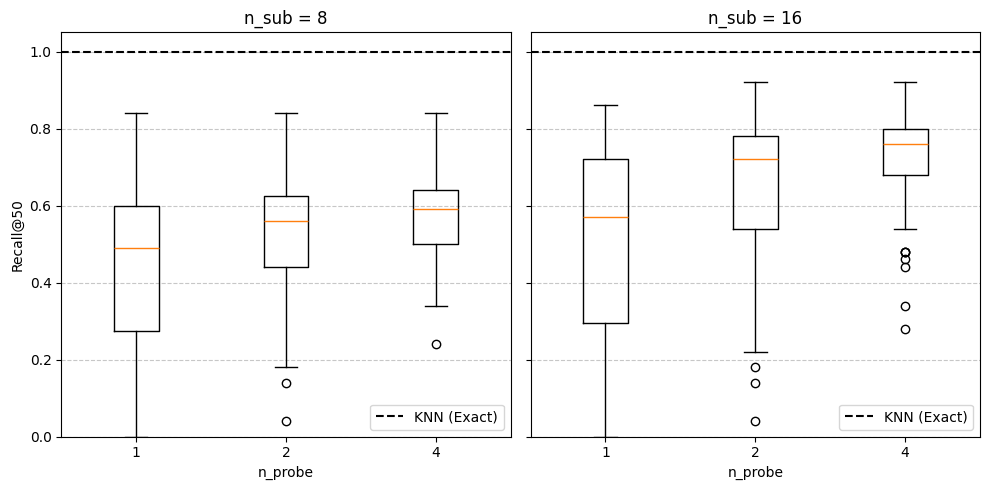

In [9]:
def compute_recall_per_query(knn_idxs, ivfpq_idxs, k):
    """
    Compute Recall@K for each query: fraction of exact KNN neighbors in IVFPQ results.
    Returns array of recalls [n_queries].
    """
    n_queries = knn_idxs.shape[0]
    recalls = []
    for q in range(n_queries):
        true_set = set(knn_idxs[q])
        approx_set = set(ivfpq_idxs[q])
        intersection = len(true_set & approx_set)
        recalls.append(intersection / k)
    return np.array(recalls)


def plot_recall_boxplot(
    knn_idxs, ivfpq_data, k_neighbors, n_subs, n_probes=[1, 4, 8, 16, 32]
):
    """
    Generate boxplot of Recall@K distributions across queries for each n_probe, grouped by n_sub.
    Assumptions:
    - knn_idxs: NumPy array [n_queries, k_neighbors] of integer indices (exact KNN neighbors).
    - ivfpq_data: dict with keys (n_sub, n_probe), values containing 'ivfpq_idxs' array.
    - k_neighbors: int, used for recall@K.
    - n_subs: list of ints, e.g., [8, 16, 32].
    - n_probes: list of ints, e.g., [1, 4, 8, 16, 32].
    - Missing data combos are skipped.
    - Outputs boxplot with subplots for each n_sub, saved as 'recall_boxplot.png'.
    """
    fig, axes = plt.subplots(1, len(n_subs), figsize=(5 * len(n_subs), 5), sharey=True)
    if len(n_subs) == 1:
        axes = [axes]  # Ensure axes is iterable for single subplot

    for i, n_sub in enumerate(n_subs):
        # Collect recall distributions for each n_probe
        recall_data = []
        labels = []
        for n_probe in n_probes:
            key = (n_sub, n_probe)
            if key in ivfpq_data:
                ivfpq_idxs = ivfpq_data[key]["ivfpq_idxs"]
                recalls = compute_recall_per_query(knn_idxs, ivfpq_idxs, k_neighbors)
                recall_data.append(recalls)
                labels.append(str(n_probe))
            else:
                recall_data.append([])  # Empty for missing data
                labels.append(str(n_probe))

        # Plot boxplot for this n_sub
        axes[i].boxplot(
            [r for r in recall_data if len(r) > 0],
            tick_labels=[l for l, r in zip(labels, recall_data) if len(r) > 0],
        )
        axes[i].set_title(f"n_sub = {n_sub}")
        axes[i].set_xlabel("n_probe")
        if i == 0:
            axes[i].set_ylabel(f"Recall@{k_neighbors}")

        # KNN baseline
        axes[i].axhline(y=1.0, color="k", linestyle="--", label="KNN (Exact)")
        axes[i].legend()
        axes[i].set_ylim(0, 1.05)
        axes[i].grid(True, axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()
    plt.savefig("notebooks/recall_boxplot.png")  # Or plt.show() for Jupyter
    plt.close()


plot_recall_boxplot(
    knn_idxs, ivfpq_data, k_neighbors=k_neighbors, n_subs=n_subs, n_probes=n_probes
)

## Mean Metrics vs. IVFPQ Parameter

Visualizes how mean Recall@K, Label Agreement, and mean Distance Distortion vary with n_probe for each n_sub, with error bars showing standard deviation across queries. This helps researchers evaluate tradeoffs in accuracy (recall and label agreement) and distortion for IVFPQ in a web app context for single-cell RNA-seq labeling, compared to a local KNN implementation. The plot uses a twin-axis format: Recall@K and Label Agreement on the left (0-1 scale), Distance Distortion on the right (data-driven scale).


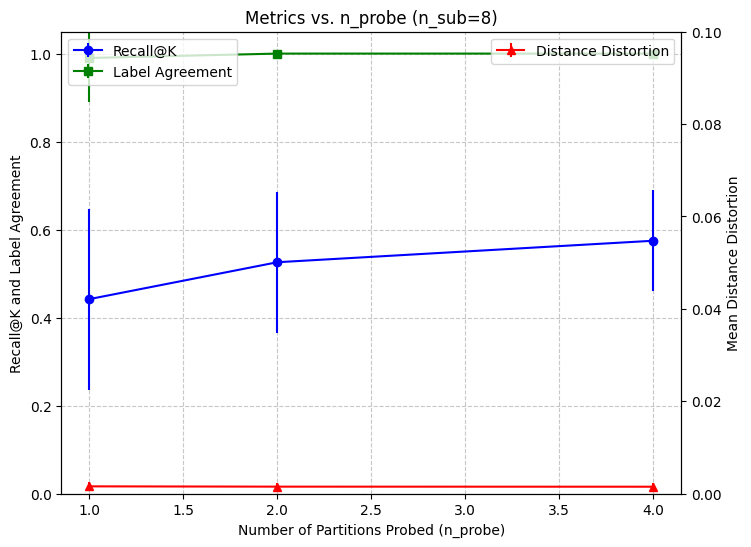

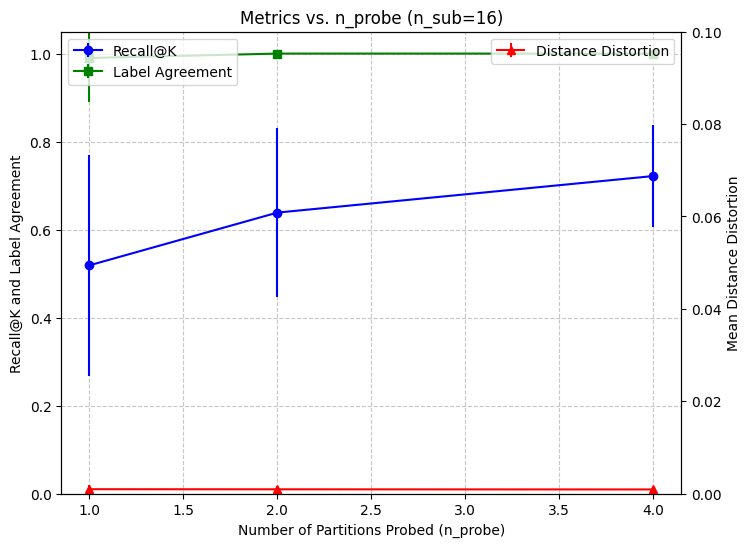

In [10]:
import numpy as np
import matplotlib.pyplot as plt


def compute_metrics_per_query(
    knn_idxs, knn_dists, knn_labels, ivfpq_idxs, ivfpq_dists, ivfpq_labels, k
):
    """
    Compute Recall@K, Label Agreement, and Distance Distortion per query.
    Returns: recalls [n_queries], agreements [n_queries], distortions [n_queries].
    """
    n_queries = knn_idxs.shape[0]
    recalls = []
    agreements = []
    distortions = []

    for q in range(n_queries):
        true_set = set(knn_idxs[q])
        approx_set = set(ivfpq_idxs[q])
        matched = true_set & approx_set
        recall = len(matched) / k
        recalls.append(recall)

        if matched:
            # Get indices in knn_idxs and ivfpq_idxs for matched neighbors
            knn_matched_idx = [np.where(knn_idxs[q] == idx)[0][0] for idx in matched]
            ivfpq_matched_idx = [
                np.where(ivfpq_idxs[q] == idx)[0][0] for idx in matched
            ]

            # Label Agreement: fraction of matched neighbors with same label
            knn_matched_labels = knn_labels[q, knn_matched_idx]
            ivfpq_matched_labels = ivfpq_labels[q, ivfpq_matched_idx]
            agreement = np.mean(knn_matched_labels == ivfpq_matched_labels)
            agreements.append(agreement)

            # Distance Distortion: mean absolute difference for matched neighbors
            knn_matched_dists = knn_dists[q, knn_matched_idx]
            ivfpq_matched_dists = ivfpq_dists[q, ivfpq_matched_idx]
            distortion = np.mean(np.abs(knn_matched_dists - ivfpq_matched_dists))
            distortions.append(distortion)
        else:
            agreements.append(0.0)  # No matched neighbors
            distortions.append(np.nan)  # No distortion if no matches

    return np.array(recalls), np.array(agreements), np.array(distortions)


def plot_metrics_vs_probes(
    knn_idxs,
    knn_dists,
    knn_labels,
    ivfpq_data,
    k_neighbors,
    n_subs,
    n_probes=range(1, 33),
):
    """
    Generate line plots of mean Recall@K, Label Agreement, and Distance Distortion vs. n_probe.
    Assumptions:
    - knn_idxs: NumPy array [n_queries, k_neighbors] of integer indices.
    - knn_dists: NumPy array [n_queries, k_neighbors] of cosine distances.
    - knn_labels: NumPy array [n_queries, k_neighbors] of labels (int/str).
    - ivfpq_data: dict with keys (n_sub, n_probe), values containing 'ivfpq_idxs', 'ivfpq_dists', 'ivfpq_labels'.
    - k_neighbors: int, for recall@K.
    - n_subs: list of ints, e.g., [8, 16, 32].
    - n_probes: range or list, e.g., range(1, 33).
    - One plot per n_sub, saved as 'metrics_vs_probes_nsubX.png'.
    """
    for n_sub in n_subs:
        means_recall = []
        stds_recall = []
        means_agree = []
        stds_agree = []
        means_distort = []
        stds_distort = []
        valid_probes = []

        for n_probe in n_probes:
            key = (n_sub, n_probe)
            if key in ivfpq_data:
                ivfpq_idxs = ivfpq_data[key]["ivfpq_idxs"]
                ivfpq_dists = ivfpq_data[key]["ivfpq_dists"]
                ivfpq_labels = ivfpq_data[key]["ivfpq_labels"]

                recalls, agreements, distortions = compute_metrics_per_query(
                    knn_idxs,
                    knn_dists,
                    knn_labels,
                    ivfpq_idxs,
                    ivfpq_dists,
                    ivfpq_labels,
                    k_neighbors,
                )

                means_recall.append(np.mean(recalls))
                stds_recall.append(np.std(recalls))
                means_agree.append(np.mean(agreements))
                stds_agree.append(np.std(agreements))
                means_distort.append(np.nanmean(distortions))  # Ignore NaNs
                stds_distort.append(np.nanstd(distortions))
                valid_probes.append(n_probe)

        # Create twin-axis line plot
        fig, ax1 = plt.subplots(figsize=(8, 6))

        # Left axis: Recall@K and Label Agreement
        ax1.errorbar(
            valid_probes,
            means_recall,
            yerr=stds_recall,
            marker="o",
            color="b",
            label="Recall@K",
        )
        ax1.errorbar(
            valid_probes,
            means_agree,
            yerr=stds_agree,
            marker="s",
            color="g",
            label="Label Agreement",
        )
        ax1.set_xlabel("Number of Partitions Probed (n_probe)")
        ax1.set_ylabel("Recall@K and Label Agreement")
        ax1.set_ylim(0, 1.05)
        ax1.legend(loc="upper left")
        ax1.grid(True, linestyle="--", alpha=0.7)

        # Right axis: Distance Distortion
        ax2 = ax1.twinx()
        ax2.errorbar(
            valid_probes,
            means_distort,
            yerr=stds_distort,
            marker="^",
            color="r",
            label="Distance Distortion",
        )
        ax2.set_ylabel("Mean Distance Distortion")
        ax2.set_ylim(
            0, max(0.1, np.nanmax(means_distort + stds_distort) * 1.1)
        )  # Adjust for data
        ax2.legend(loc="upper right")

        plt.title(f"Metrics vs. n_probe (n_sub={n_sub})")
        plt.show()
        plt.savefig(f"notebooks/metrics_vs_probes_nsub{n_sub}.png")
        plt.close()


# Example usage (replace with your data)
# knn_idxs = np.array([...])  # Shape: [n_queries, k_neighbors]
# knn_dists = np.array([...])  # Shape: [n_queries, k_neighbors]
# knn_labels = np.array([...])  # Shape: [n_queries, k_neighbors], e.g., ['T-cell', 'B-cell', ...]
# ivfpq_data = {
#     (8,1): {'ivfpq_idxs': np.array([...]), 'ivfpq_dists': np.array([...]), 'ivfpq_labels': np.array([...])},
#     (8,4): {'ivfpq_idxs': np.array([...]), 'ivfpq_dists': np.array([...]), 'ivfpq_labels': np.array([...])},
#     # ... for all combos
# }
plot_metrics_vs_probes(
    knn_idxs,
    knn_dists,
    knn_labels,
    ivfpq_data,
    k_neighbors=k_neighbors,
    n_subs=n_subs,
    n_probes=n_probes,
)

## Distance Distortion vs. Recall@K

Relationship between mean distance distortion (for matched neighbors) and Recall@K for each query, with points colored by the average nearest neighbor distance in single-cell RNA-seq data (nn_dist_SC, reflecting query "difficulty"). This helps researchers understand if queries with farther neighbors (harder cases) exhibit higher distortion or lower recall in IVFPQ compared to KNN, relevant for web app vs. local tool tradeoffs.


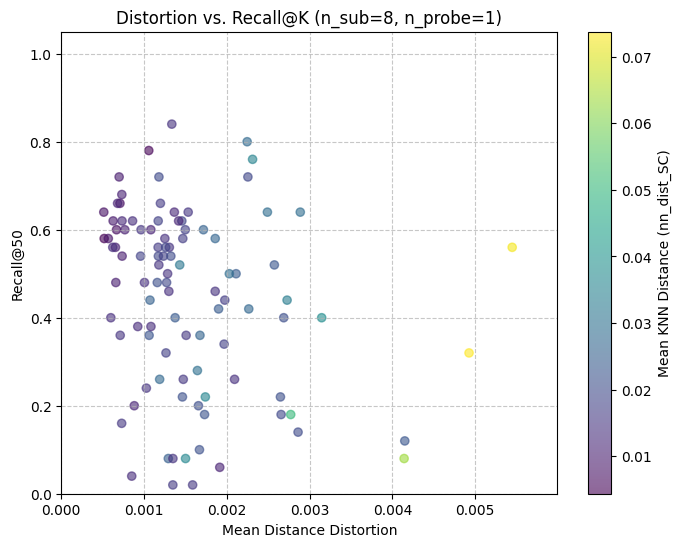

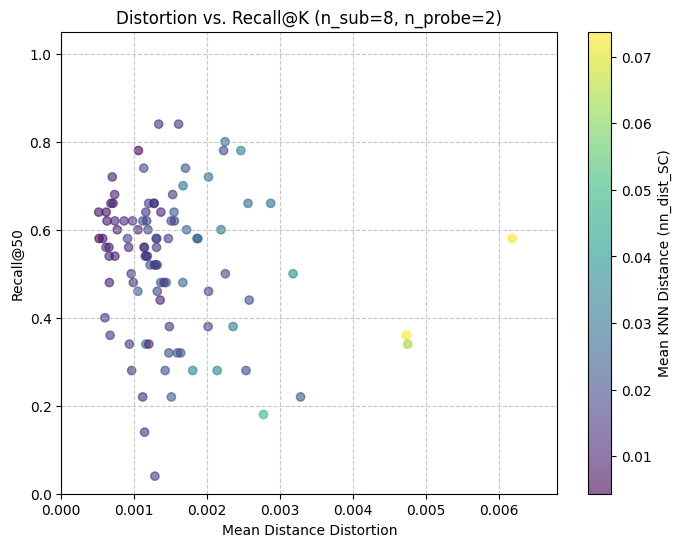

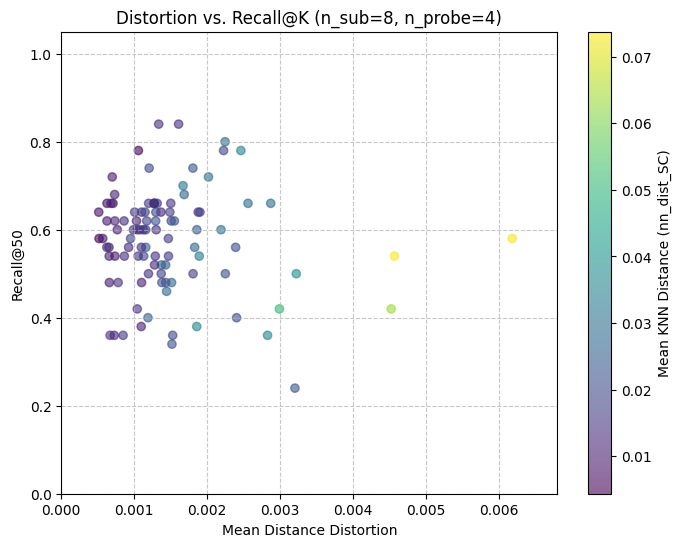

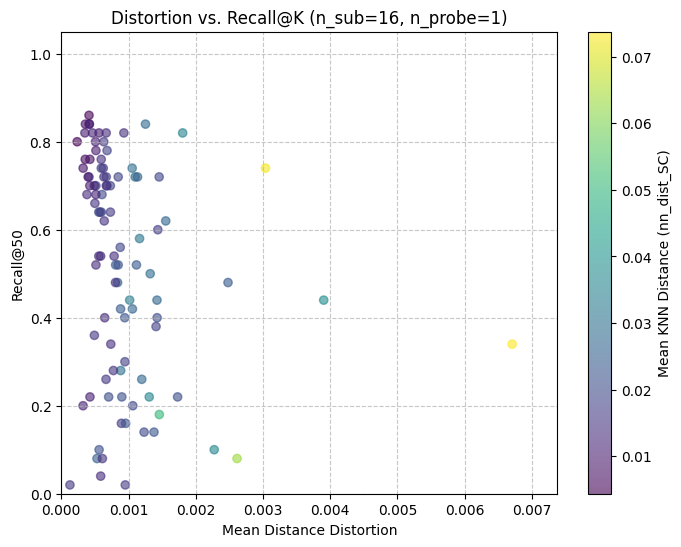

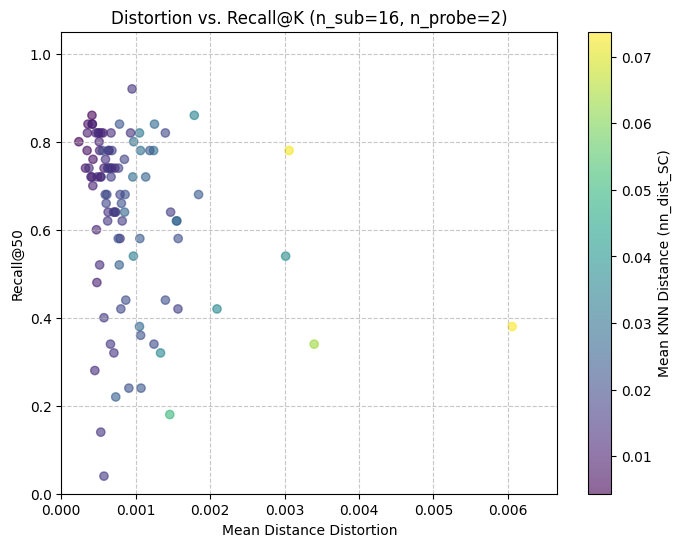

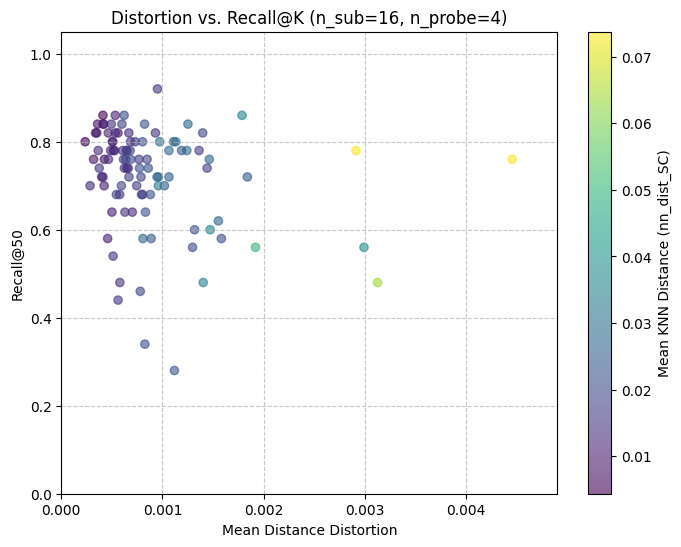

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm


def compute_metrics_per_query(knn_idxs, knn_dists, ivfpq_idxs, ivfpq_dists, k):
    """
    Compute Recall@K and mean distance distortion per query.
    - Recall@K: Fraction of exact KNN neighbors in IVFPQ results.
    - Distortion: Mean absolute difference in cosine distances for matched neighbors.
    Returns: recalls [n_queries], distortions [n_queries].
    """
    n_queries = knn_idxs.shape[0]
    recalls = []
    distortions = []

    for q in range(n_queries):
        true_set = set(knn_idxs[q])
        approx_set = set(ivfpq_idxs[q])
        matched = true_set & approx_set
        recall = len(matched) / k
        recalls.append(recall)

        if matched:
            # Get indices in knn_idxs and ivfpq_idxs for matched neighbors
            knn_matched_idx = [np.where(knn_idxs[q] == idx)[0][0] for idx in matched]
            ivfpq_matched_idx = [
                np.where(ivfpq_idxs[q] == idx)[0][0] for idx in matched
            ]
            knn_matched_dists = knn_dists[q, knn_matched_idx]
            ivfpq_matched_dists = ivfpq_dists[q, ivfpq_matched_idx]
            distortion = np.mean(np.abs(knn_matched_dists - ivfpq_matched_dists))
        else:
            distortion = np.nan  # No matched neighbors
        distortions.append(distortion)

    return np.array(recalls), np.array(distortions)


def plot_distortion_vs_recall(
    knn_idxs, knn_dists, ivfpq_data, k_neighbors, n_subs, n_probes=[1, 4, 8, 16, 32]
):
    """
    Generate scatter plots of mean distance distortion vs. Recall@K per query, colored by nn_dist_SC.
    Assumptions:
    - knn_idxs: NumPy array [n_queries, k_neighbors] of integer indices.
    - knn_dists: NumPy array [n_queries, k_neighbors] of cosine distances.
    - ivfpq_data: dict with keys (n_sub, n_probe), values containing 'ivfpq_idxs', 'ivfpq_dists'.
    - k_neighbors: int, for recall@K.
    - n_subs: list of ints, e.g., [8, 16, 32].
    - n_probes: list of ints, e.g., [1, 4, 8, 16, 32].
    - nn_dist_SC: mean of knn_dists per query [n_queries].
    - One plot per (n_sub, n_probe), saved as 'distortion_vs_recall_nsubX_nprobeY.png'.
    """
    # Compute nn_dist_SC (mean KNN distance per query)
    nn_dist_SC = np.mean(knn_dists, axis=1)

    for n_sub in n_subs:
        for n_probe in n_probes:
            key = (n_sub, n_probe)
            if key not in ivfpq_data:
                continue

            ivfpq_idxs = ivfpq_data[key]["ivfpq_idxs"]
            ivfpq_dists = ivfpq_data[key]["ivfpq_dists"]

            # Compute per-query metrics
            recalls, distortions = compute_metrics_per_query(
                knn_idxs, knn_dists, ivfpq_idxs, ivfpq_dists, k_neighbors
            )

            # Create scatter plot
            plt.figure(figsize=(8, 6))
            scatter = plt.scatter(
                distortions, recalls, c=nn_dist_SC, cmap="viridis", alpha=0.6
            )
            plt.colorbar(scatter, label="Mean KNN Distance (nn_dist_SC)")
            plt.xlabel("Mean Distance Distortion")
            plt.ylabel(f"Recall@{k_neighbors}")
            plt.title(f"Distortion vs. Recall@K (n_sub={n_sub}, n_probe={n_probe})")
            plt.grid(True, linestyle="--", alpha=0.7)
            plt.xlim(0, np.nanmax(distortions) * 1.1 if np.any(distortions) else 1.0)
            plt.ylim(0, 1.05)

            plt.show()
            plt.savefig(
                f"notebooks/distortion_vs_recall_nsub{n_sub}_nprobe{n_probe}.png"
            )
            plt.close()


# Example usage (replace with your data)
# knn_idxs = np.array([...])  # Shape: [n_queries, k_neighbors]
# knn_dists = np.array([...])  # Shape: [n_queries, k_neighbors]
# ivfpq_data = {
#     (8,1): {'ivfpq_idxs': np.array([...]), 'ivfpq_dists': np.array([...])},
#     (8,4): {'ivfpq_idxs': np.array([...]), 'ivfpq_dists': np.array([...])},
#     # ... for all combos
# }
plot_distortion_vs_recall(
    knn_idxs,
    knn_dists,
    ivfpq_data,
    k_neighbors=k_neighbors,
    n_subs=n_subs,
    n_probes=n_probes,
)